# Level 1 · Part 1 — From raw spatial output to clean cells

Welcome to Level 1! You are given the raw output of an **image-based spatial
transcriptomics** experiment: a large tissue section imaged with a **300-gene MERSCOPE
(Vizgen) panel**. For every cell the instrument reports where it is, which transcripts
fall inside it, and the underlying microscopy images.

Before we can say anything biological, we need to answer two questions:

1. **What did the instrument actually measure?** — images, transcripts, cells, and how
   they relate in space.
2. **Which cells can we trust?** — quality control, and (in Part 2) whether the *cell
   boundaries* themselves are any good.

In this notebook we **load** the data, **look** at it from several angles to build
intuition, run **QC**, and finally **carve out a small working region** that you will
segment in Part 2.

> 📖 **Read more.** The data is stored as a `SpatialData` object — skim the
> [SpatialData introduction](https://spatialdata.scverse.org/en/stable/tutorials/notebooks/notebooks/examples/intro.html)
> and keep the [SpatialData](https://spatialdata.scverse.org) /
> [squidpy](https://squidpy.readthedocs.io) docs open as you go.

## 0. Setup

In [1]:
from pathlib import Path
import shutil

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

import spatialdata as sd
import spatialdata_plot  # noqa: F401  (registers the `.pl` plotting accessor)
from spatialdata import bounding_box_query
from spatialdata.models import Image2DModel
from spatialdata.transformations import get_transformation

sc.settings.verbosity = 1

# The raw section is staged once, read-only and shared by everyone. Never write here.
SHARED_ZARR = ("/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/"
               "data/wang2025_merfish/processed/UCSF2018-003-MFG_baseline.zarr")

# Your own writable working directory (in your home). Your crop + segmentations go here.
WORK_DIR = Path.home() / "c15_l1_work"
WORK_DIR.mkdir(exist_ok=True)
print("working dir:", WORK_DIR)

working dir: /shared/home/tp185001/c15_l1_work


## 1. Load the data (read-only) and look at its structure

A `SpatialData` object is a container that keeps every layer of a spatial experiment in
**one coordinate system**:

- **`images`** — the raw microscopy (here: DAPI = nuclei, poly(T) = total RNA),
- **`points`** — the individual detected transcripts (one row per molecule),
- **`shapes`** — cell boundaries (polygons); here the *vendor's* segmentation,
- **`tables`** — an `AnnData` cell × gene count matrix aligned to the shapes.

🔬 **Task 1.1** — Load the object and inspect what's inside.

In [2]:
sdata = sd.read_zarr(SHARED_ZARR)
sdata

SpatialData object, with associated Zarr store: /shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/data/wang2025_merfish/processed/UCSF2018-003-MFG_baseline.zarr
├── Images
│     └── 'raw_UCSF2018-003-MFG_z3': DataTree[cyx] (2, 81685, 122429), (2, 40842, 61214), (2, 20421, 30607), (2, 10210, 15303), (2, 5105, 7651)
├── Points
│     └── 'raw_UCSF2018-003-MFG_transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     └── 'authors_cells': GeoDataFrame shape: (90962, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (90962, 300)
with coordinate systems:
    ▸ 'global', with elements:
        raw_UCSF2018-003-MFG_z3 (Images), raw_UCSF2018-003-MFG_transcripts (Points), authors_cells (Shapes)

In [3]:
image_key = list(sdata.images)[0]
points_key = list(sdata.points)[0]
shapes_key = list(sdata.shapes)[0]

full_res = sdata[image_key]["scale0"]["image"]
print("image  :", image_key, "| shape (C, Y, X) =", tuple(full_res.shape),
      "| channels:", [str(c) for c in full_res.coords["c"].values])
print("points :", points_key, "(individual transcripts)")
print("shapes :", shapes_key, "->", f"{len(sdata[shapes_key]):,}", "vendor cell polygons")
print("table  :", sdata["table"].shape, "(cells x genes)")
sdata["table"].obs.head()

image  : raw_UCSF2018-003-MFG_z3 | shape (C, Y, X) = (2, 81685, 122429) | channels: ['0', '1']
points : raw_UCSF2018-003-MFG_transcripts (individual transcripts)
shapes : authors_cells -> 90,962 vendor cell polygons
table  : (90962, 300) (cells x genes)


,fov,volume,center_x,center_y,min_x,max_x,min_y,max_y,region,cell_id
101067008445093297288543868591711571904,1708,432.610492,9022.967727,8675.046478,9016.271727,9029.663727,8667.756478,8682.336479,authors_cells,101067008445093297288543868591711571904
105357147726523176873582916346412554223,1708,402.031857,9006.551727,8694.864479,9000.719727,9012.383727,8686.980479,8702.748479,authors_cells,105357147726523176873582916346412554223
107772685775781971856545684617115638457,1708,514.041255,9171.683731,8651.070478,9164.231731,9179.135731,8643.996478,8658.144478,authors_cells,107772685775781971856545684617115638457
109560164495623483514085236461669788878,1708,1519.930087,9131.615730,8802.270482,9122.003730,9141.227730,8793.468482,8811.072482,authors_cells,109560164495623483514085236461669788878
124146632065535810248674469784684919963,1708,159.633512,9062.333728,8663.814478,9057.419728,9067.247728,8659.008478,8668.620478,authors_cells,124146632065535810248674469784684919963


❓ **Question.** The image is stored *multiscale* (a pyramid: `scale0`, `scale1`, …).
Why is that essential for a section that is ~120,000 × 80,000 pixels? (Hint: think about
what you need when you zoom out to see the whole tissue vs. zoom in on a few cells.)

> 📖 The images are in **pixel** space; transcripts and shapes are stored in **microns**
> and carry a micron→pixel transformation. This is the "coordinate systems" idea from the
> SpatialData intro — it's what lets us overlay all layers correctly.

## 2. The whole section — DAPI and poly(T)

Let's simply *look* at the tissue. `spatialdata-plot` automatically renders from a
coarse pyramid level, so plotting the entire section is cheap.

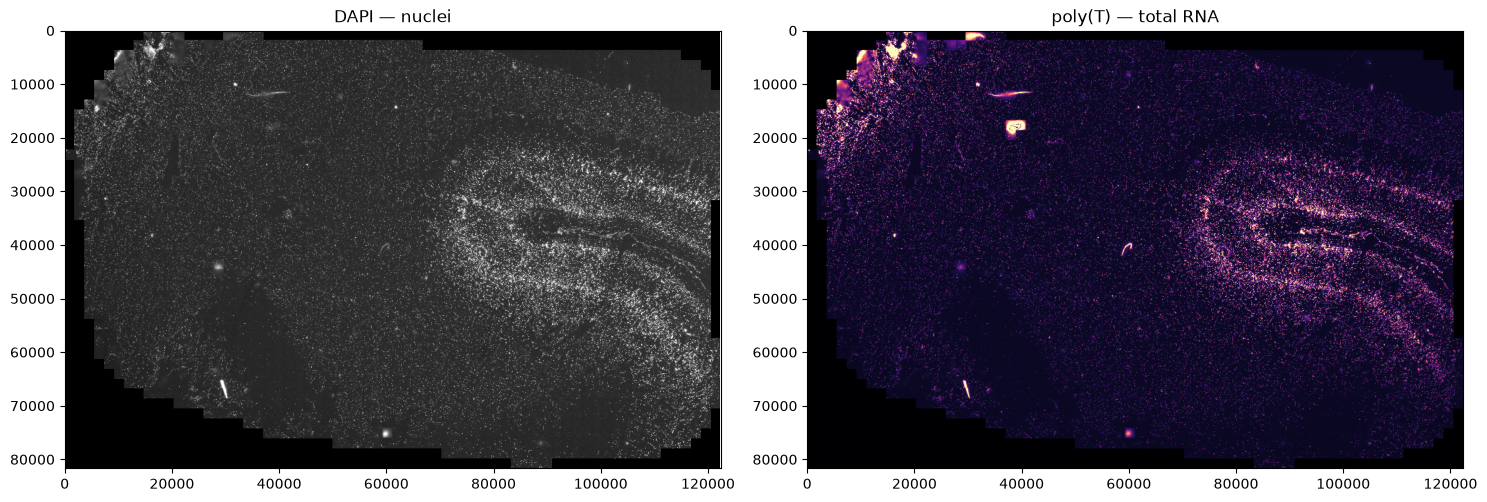

In [4]:
# Pick display contrast from a coarse pyramid level: the tissue is dim except a few
# bright spots, so we clip at the 99.5th percentile instead of the raw max.
coarse = sdata[image_key]["scale4"]["image"]
dapi_norm = mcolors.Normalize(0, float(np.percentile(np.asarray(coarse.sel(c=0)), 99.5)))
polyt_norm = mcolors.Normalize(0, float(np.percentile(np.asarray(coarse.sel(c=1)), 99.5)))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
sdata.pl.render_images(image_key, channel=0, cmap="gray", norm=dapi_norm, colorbar=False).pl.show(
    ax=axes[0], title="DAPI — nuclei")
sdata.pl.render_images(image_key, channel=1, cmap="magma", norm=polyt_norm, colorbar=False).pl.show(
    ax=axes[1], title="poly(T) — total RNA")
fig.tight_layout()

❓ **Question.** DAPI stains **nuclei**; poly(T) marks **total mRNA** (roughly, cytoplasm).
Where do you already see structure — layers, dense vs. sparse regions? Cell segmentation
will have to turn these smooth intensities into discrete cells.

## 3. Zoom in — cells, boundaries, and transcripts

Now zoom to a small window and overlay the three layers. We centre on the tissue using
the median cell position, and convert microns → pixels with the stored transformation.

In [5]:
# micron -> pixel affine (transcripts are micron-native; the image is in pixels)
affine = get_transformation(sdata[points_key], get_all=True)["global"]
M = affine.to_affine_matrix(input_axes=("x", "y"), output_axes=("x", "y"))
px_per_um = float(M[0, 0])

# centre the window on the tissue (median vendor-cell centroid), in microns then pixels
centroids = sdata[shapes_key].geometry.centroid
cx_um, cy_um = float(centroids.x.median()), float(centroids.y.median())
cx_px = M[0, 0] * cx_um + M[0, 1] * cy_um + M[0, 2]
cy_px = M[1, 0] * cx_um + M[1, 1] * cy_um + M[1, 2]

WIN_UM = 150  # a small field of view
half = px_per_um * WIN_UM
view = bounding_box_query(
    sdata, axes=("x", "y"),
    min_coordinate=[cx_px - half, cy_px - half],
    max_coordinate=[cx_px + half, cy_px + half],
    target_coordinate_system="global",
)
print(f"1 micron = {px_per_um:.2f} pixels | window = {WIN_UM} um")

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


1 micron = 9.26 pixels | window = 150 um


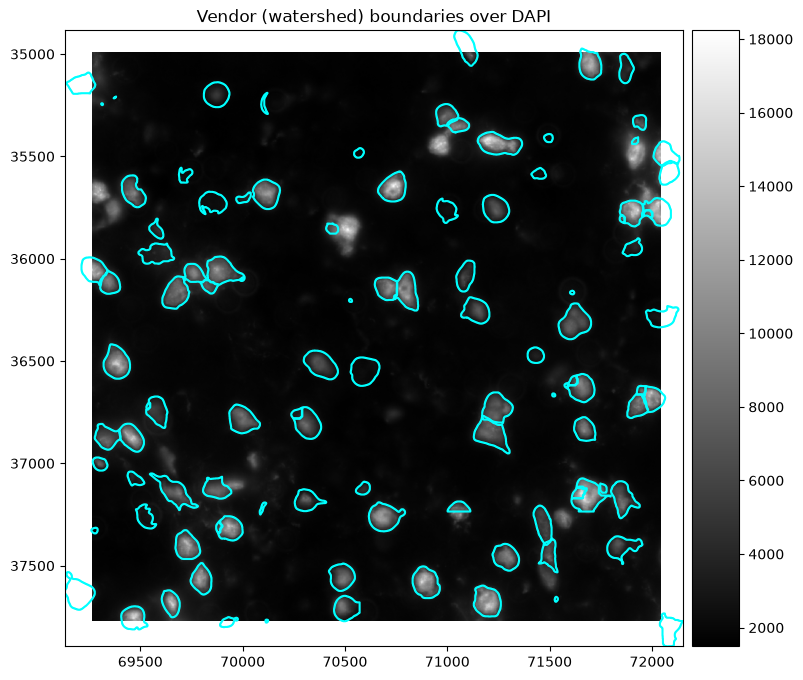

In [6]:
# vendor cell boundaries over DAPI
fig, ax = plt.subplots(figsize=(8, 8))
(view.pl.render_images(image_key, channel=0, cmap="gray")
     .pl.render_shapes(shapes_key, fill_alpha=0, outline_alpha=1, outline_color="cyan")
     .pl.show(ax=ax, title="Vendor (watershed) boundaries over DAPI"))

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


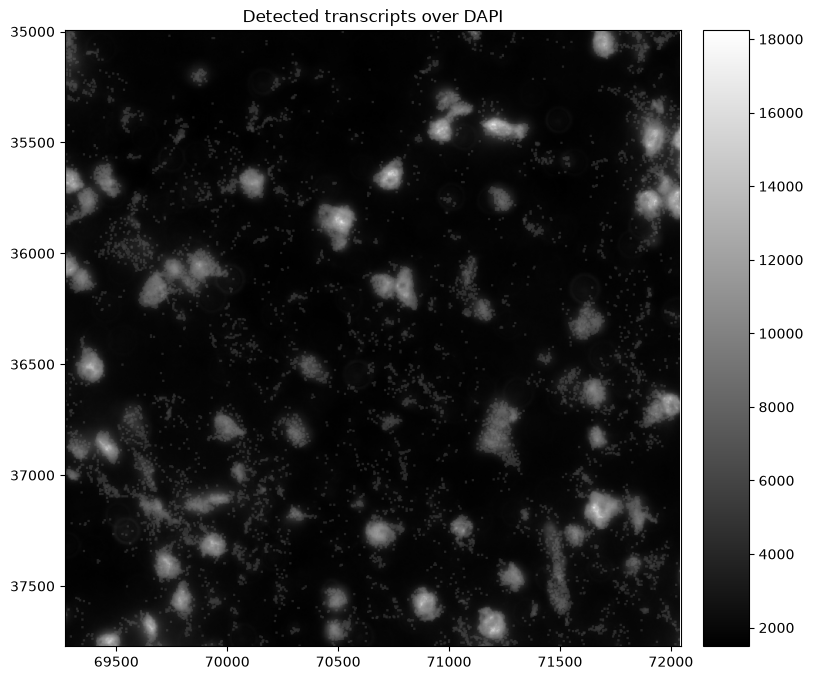

In [7]:
# the raw transcripts (each point is one detected mRNA molecule) over DAPI
fig, ax = plt.subplots(figsize=(8, 8))
(view.pl.render_images(image_key, channel=0, cmap="gray")
     .pl.render_points(points_key, color="gray", size=2, alpha=0.5)
     .pl.show(ax=ax, title="Detected transcripts over DAPI"))

🔬 **Exercise 3.1** — Make the data your own:

- move the window to a different part of the section (change `cx_px` / `cy_px`),
- shrink/grow `WIN_UM`,
- colour the transcripts by a **gene** instead of grey: pass `color="gene"` (and, e.g.,
  `groups=["<GENE>"]`) to `render_points`. Pick any gene from `sdata["table"].var_names`.

> 📖 More overlays and options: the
> [SpatialData plotting](https://spatialdata.scverse.org/projects/spatialdata-plot/en/latest/)
> gallery and the squidpy
> [MERFISH tutorial](https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_vizgen.html).

❓ **Question.** Look at the cyan boundaries vs. the DAPI signal and the transcript cloud.
Do the vendor cells look convincing? Are any nuclei merged into one cell, or split? Hold
that thought — quantifying it is the whole point of Part 2.

## 4. Quality control on the vendor cells

Every spatial dataset needs QC. The vendor `table` holds **raw transcript counts** per
cell, so we can compute the standard per-cell metrics with `scanpy`.

In [8]:
adata = sdata["table"].copy()
adata.layers["counts"] = adata.X.copy()  # keep the raw counts
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)

qc_cols = ["total_counts", "n_genes_by_counts", "volume"]
adata.obs[qc_cols].describe().round(1)

,total_counts,n_genes_by_counts,volume
count,90962.0,90962.0,90962.0
mean,61.3,23.5,758.4
std,77.9,22.2,523.6
min,0.0,0.0,0.0
25%,5.0,4.0,284.9
50%,35.0,19.0,703.6
75%,88.0,36.0,1174.2
max,1984.0,160.0,10119.4


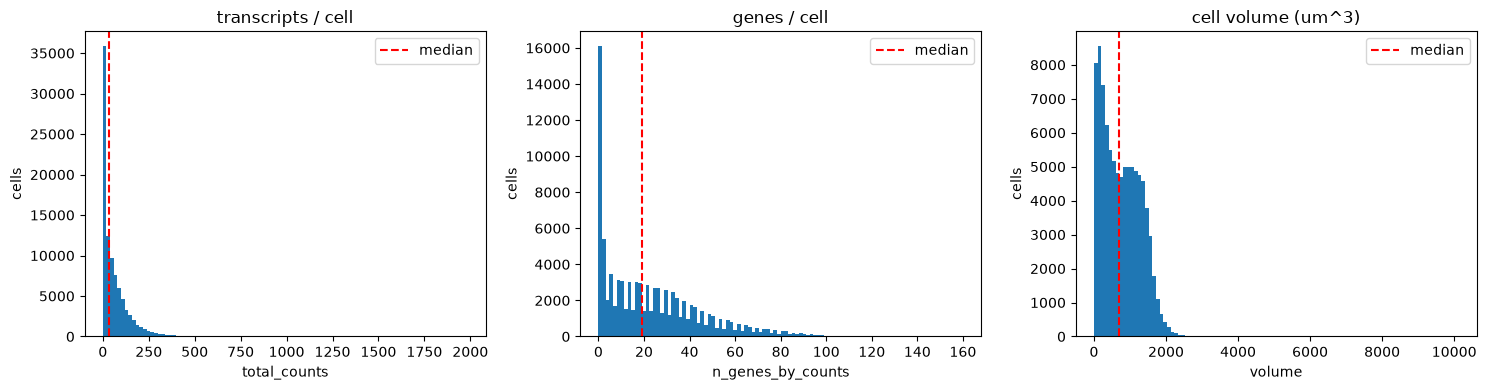

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(
    axes, qc_cols, ["transcripts / cell", "genes / cell", "cell volume (um^3)"], strict=True,
):
    ax.hist(adata.obs[col], bins=100)
    ax.set(title=label, xlabel=col, ylabel="cells")
    ax.axvline(adata.obs[col].median(), color="red", ls="--", label="median")
    ax.legend()
fig.tight_layout()

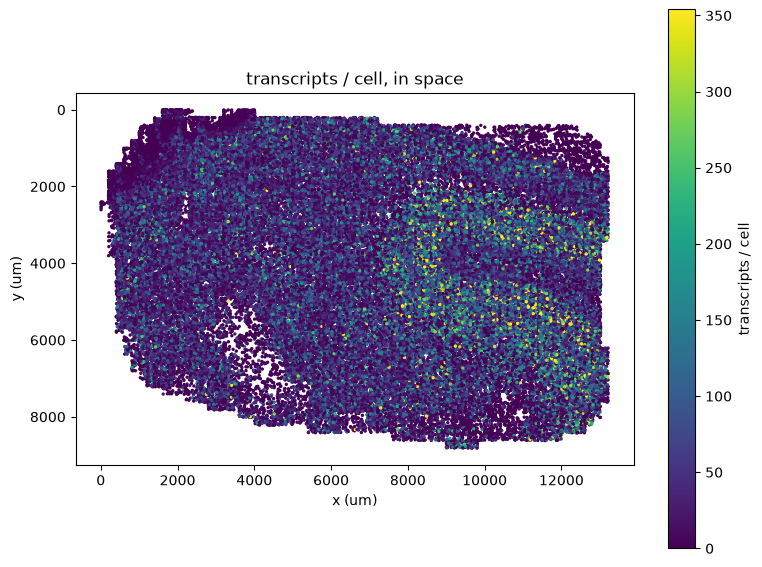

In [10]:
# QC has a spatial dimension too: colour each cell by its transcript count in tissue space
xy = adata.obsm["spatial"]
vmax = np.percentile(adata.obs["total_counts"], 99)

fig, ax = plt.subplots(figsize=(9, 7))
sca = ax.scatter(xy[:, 0], xy[:, 1], c=adata.obs["total_counts"], s=2, cmap="viridis", vmax=vmax)
ax.set(title="transcripts / cell, in space", xlabel="x (um)", ylabel="y (um)")
ax.set_aspect("equal")
ax.invert_yaxis()
fig.colorbar(sca, ax=ax, label="transcripts / cell")

❓ **Question.** Typical MERSCOPE QC would drop cells with very few transcripts, very few
genes, or implausible volumes. From the histograms, roughly where would *you* put those
thresholds — and does the spatial map suggest the low-count cells are random noise or
structured (e.g. a whole region)?

💡 **Note.** We deliberately **don't** filter here. Level 1 is about the **segmentation**
itself: a bad segmentation *creates* bad cells (merged doublets, sliced fragments), so in
Part 2 we compare segmentation strategies before committing to any QC.

## 5. Carve out your working region → save it to your home

Segmenting the whole section four different ways is far too heavy for a laptop-sized,
interactive session. Instead, each of you takes the **same fixed ~600 µm crop** — big
enough to span several cortical depths (so many cell types are present), small enough to
segment in minutes.

We first show *where* the crop sits, then write it to **your home directory** as its own
small `SpatialData` — a writable copy you own and will segment in Part 2.

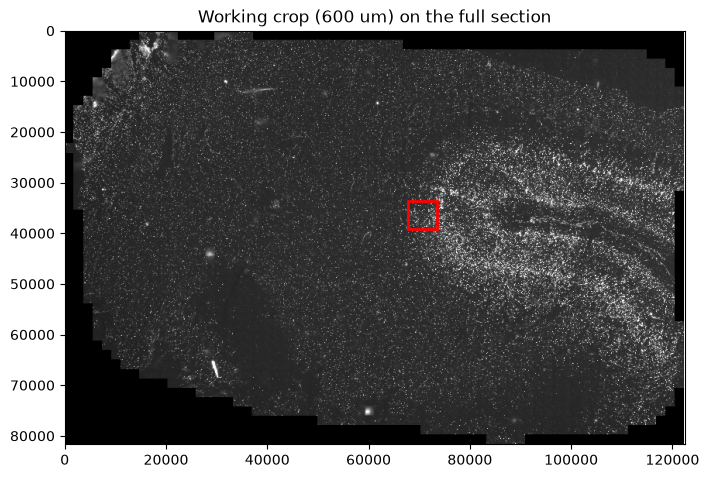

In [11]:
CROP_UM = 600
crop_half = px_per_um * CROP_UM / 2
cmin = [cx_px - crop_half, cy_px - crop_half]
cmax = [cx_px + crop_half, cy_px + crop_half]

fig, ax = plt.subplots(figsize=(8, 6))
sdata.pl.render_images(image_key, channel=0, cmap="gray", norm=dapi_norm, colorbar=False).pl.show(
    ax=ax, title=f"Working crop ({CROP_UM} um) on the full section")
ax.add_patch(Rectangle((cmin[0], cmin[1]), 2 * crop_half, 2 * crop_half,
                       edgecolor="red", facecolor="none", lw=2))

In [12]:
crop = bounding_box_query(
    sdata, axes=("x", "y"), min_coordinate=cmin, max_coordinate=cmax,
    target_coordinate_system="global",
)

# name the image channels (DAPI / PolyT) so the segmentation step can refer to them
img = crop[image_key]
full = img["scale0"]["image"]
crop[image_key] = Image2DModel.parse(
    full.data, dims=tuple(full.dims), c_coords=["DAPI", "PolyT"],
    scale_factors=[2, 2, 2, 2], transformations=get_transformation(img, get_all=True),
)

CROP_ZARR = WORK_DIR / "crop.zarr"
shutil.rmtree(CROP_ZARR, ignore_errors=True)
crop.write(CROP_ZARR)
print("wrote crop to", CROP_ZARR)
crop

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/site-packages/dask/utils.py:782: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Affine is not JSON serializable, defaulting to empty attributes.
  return meth(arg, *args, **kwargs)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/site-packages/dask/dataframe/io/parquet/arrow.py:824: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Affine is not JSON serializable, defaulting to empty attributes.
  t = cls._pandas_to_arrow_table(df, preserve_index=preserve_index, schema=schema)


/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the 

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the 

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)


wrote crop to /shared/home/tp185001/c15_l1_work/crop.zarr


SpatialData object, with associated Zarr store: /shared/home/tp185001/c15_l1_work/crop.zarr
├── Images
│     └── 'raw_UCSF2018-003-MFG_z3': DataTree[cyx] (2, 5555, 5556), (2, 2777, 2778), (2, 1388, 1389), (2, 694, 694), (2, 347, 347)
├── Points
│     └── 'raw_UCSF2018-003-MFG_transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     └── 'authors_cells': GeoDataFrame shape: (444, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (444, 300)
with coordinate systems:
    ▸ 'global', with elements:
        raw_UCSF2018-003-MFG_z3 (Images), raw_UCSF2018-003-MFG_transcripts (Points), authors_cells (Shapes)
with the following Dask-backed elements not being self-contained:
    ▸ raw_UCSF2018-003-MFG_z3: /shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/data/wang2025_merfish/processed/UCSF2018-003-MFG_baseline.zarr/images/raw_UCSF2018-003-MFG_z3

## Summary & what's next

You have:

- loaded a real image-based spatial dataset and understood its layers (images, points,
  shapes, table) and coordinate systems,
- built visual intuition — whole section, a zoomed field of view with boundaries and
  transcripts, and the spatial structure of QC,
- carved out a **600 µm working crop** saved in your home.

➡️ **Part 2 (`02_segmentation_and_metric`)**: you'll re-segment this crop four different
ways, look at the results, compare them, and decide — with a metric — which segmentation
to trust. As you'll see, the *vendor* boundaries you just looked at may not be the best.

> 📖 **Read more before Part 2.** Skim the [Sopa](https://prism-oncology.github.io/sopa/)
> docs (the pipeline we'll use) and the
> [Sopa "compare segmentations" tutorial](https://prism-oncology.github.io/sopa/tutorials/compare_segmentations/).